# Baseline Classifier Training
## Adversarial Robustness Testing & Trust Safety Pipeline



## Imports

In [1]:
import os
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.models as models
import torchvision.transforms as transforms
from PIL import Image

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score
)

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Device
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")
if DEVICE.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
else:
    print("Running on CPU — training will be slower but will complete fine.")

print(f"PyTorch version: {torch.__version__}")


Device: cpu
Running on CPU — training will be slower but will complete fine.
PyTorch version: 2.8.0+cpu


## Configuration

In [2]:
# Paths
PROJECT_DIR     = Path(r"C:/adversarial_doc_project")
DATA_DIR        = PROJECT_DIR / "data"
SPLITS_DIR      = DATA_DIR / "splits"
OUTPUTS_DIR     = PROJECT_DIR / "outputs"
CHECKPOINTS_DIR = PROJECT_DIR / "checkpoints"

# Training config 
IMG_SIZE        = 224
BATCH_SIZE      = 16      # Reduce to 8 if you get memory errors
NUM_EPOCHS      = 10      # 10 epochs gives a solid baseline
LEARNING_RATE   = 1e-4
NUM_CLASSES     = 3       # 0=real, 1=benign, 2=malicious
NUM_WORKERS     = 0       # 0 = no multiprocessing (safe on Windows)

# Class names 
CLASS_NAMES = {0: "real", 1: "benign", 2: "malicious"}
CLASS_LIST  = ["real", "benign", "malicious"]

# Verify paths exist
assert SPLITS_DIR.exists(), f"Splits not found at {SPLITS_DIR}. Run Week 1 first."
assert (SPLITS_DIR / "train.csv").exists(), "train.csv not found. Run Week 1 first."

print("Configuration ready.")
print(f"Project dir : {PROJECT_DIR}")
print(f"Batch size  : {BATCH_SIZE}")
print(f"Epochs      : {NUM_EPOCHS}")
print(f"Classes     : {CLASS_LIST}")
print(f"Device      : {DEVICE}")


Configuration ready.
Project dir : C:\adversarial_doc_project
Batch size  : 16
Epochs      : 10
Classes     : ['real', 'benign', 'malicious']
Device      : cpu


## Load Data

At this stage all frames are labelled as class 0 (real).
The benign (class 1) and malicious (class 2) samples will be
generated and added in Week 3. This week we train on real frames
only to establish a baseline, then evaluate how the model
performs before any adversarial training.


In [3]:
# Load splits
train_df = pd.read_csv(SPLITS_DIR / "train.csv")
val_df   = pd.read_csv(SPLITS_DIR / "val.csv")
test_df  = pd.read_csv(SPLITS_DIR / "test.csv")

print(f"Train frames : {len(train_df)}")
print(f"Val frames   : {len(val_df)}")
print(f"Test frames  : {len(test_df)}")
print(f"\nLabel distribution in train:")
print(train_df["label"].value_counts().to_string())
print(f"\nSample row:")
print(train_df.iloc[0].to_string())


Train frames : 4900
Val frames   : 1050
Test frames  : 1050

Label distribution in train:
label
0    4900

Sample row:
frame_path    C:\adversarial_doc_project\data\frames\midv201...
dataset                                                midv2019
clip_name                              midv2019_videos_DG01_mp4
label                                                         0
label_name                                                 real
split                                                     train


## Build PyTorch Dataset & Dataloaders

In [4]:
class DocumentDataset(Dataset):
    """
    PyTorch Dataset for identity document frames.
    Loads images from disk, applies transforms, returns (image, label).
    """
    def __init__(self, dataframe, transform=None):
        self.df        = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        path  = row["frame_path"]
        label = int(row["label"])

        # Load image
        img = Image.open(path).convert("RGB")

        if self.transform:
            img = self.transform(img)

        return img, label


# Transforms 
# Train: augmentation to improve generalisation
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.3),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.RandomRotation(degrees=5),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Val/Test: no augmentation — just resize and normalise
val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Datasets 
train_dataset = DocumentDataset(train_df, transform=train_transform)
val_dataset   = DocumentDataset(val_df,   transform=val_transform)
test_dataset  = DocumentDataset(test_df,  transform=val_transform)

# Dataloaders 
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=NUM_WORKERS)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=NUM_WORKERS)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=NUM_WORKERS)

print(f"Train batches : {len(train_loader)}")
print(f"Val batches   : {len(val_loader)}")
print(f"Test batches  : {len(test_loader)}")

# Quick sanity check — load one batch
imgs, labels = next(iter(train_loader))
print(f"\nBatch image shape : {imgs.shape}")
print(f"Batch label shape : {labels.shape}")
print(f"Label values      : {labels.tolist()}")
print("Dataset and dataloaders ready.")


Train batches : 307
Val batches   : 66
Test batches  : 66

Batch image shape : torch.Size([16, 3, 224, 224])
Batch label shape : torch.Size([16])
Label values      : [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Dataset and dataloaders ready.


## Build EfficientNet-B0 Classifier

EfficientNet-B0 is chosen as the primary model because:
- Best accuracy-to-parameter ratio for small datasets
- Pre-trained on ImageNet — transfer learning from day 1
- Widely cited in document classification literature


In [5]:
def build_efficientnet(num_classes=3, pretrained=True):
    """
    Build EfficientNet-B0 with a custom classification head.
    Replaces the final layer with a num_classes output.
    """
    weights = models.EfficientNet_B0_Weights.IMAGENET1K_V1 if pretrained else None
    model   = models.efficientnet_b0(weights=weights)

    # Replace classifier head
    in_features = model.classifier[1].in_features
    model.classifier[1] = nn.Linear(in_features, num_classes)

    return model


# Build model
model = build_efficientnet(num_classes=NUM_CLASSES, pretrained=True)
model = model.to(DEVICE)

# Count parameters
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("Model: EfficientNet-B0")
print(f"Total parameters    : {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Output classes      : {NUM_CLASSES} {CLASS_LIST}")
print(f"Device              : {next(model.parameters()).device}")

# Quick forward pass test
with torch.no_grad():
    test_input  = torch.randn(2, 3, IMG_SIZE, IMG_SIZE).to(DEVICE)
    test_output = model(test_input)
    print(f"\nTest forward pass output shape: {test_output.shape}")
print("Model ready.")


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to C:\Users\chaar/.cache\torch\hub\checkpoints\efficientnet_b0_rwightman-7f5810bc.pth


100%|█████████████████████████████████████████████████████████████████████████████| 20.5M/20.5M [00:00<00:00, 61.4MB/s]


Model: EfficientNet-B0
Total parameters    : 4,011,391
Trainable parameters: 4,011,391
Output classes      : 3 ['real', 'benign', 'malicious']
Device              : cpu

Test forward pass output shape: torch.Size([2, 3])
Model ready.


## Training and Evaluation Functions

In [6]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    """Train for one epoch. Returns average loss and accuracy."""
    model.train()
    total_loss = 0.0
    correct    = 0
    total      = 0

    for imgs, labels in tqdm(loader, desc="Training", leave=False):
        imgs   = imgs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(imgs)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        preds       = outputs.argmax(dim=1)
        correct    += (preds == labels).sum().item()
        total      += labels.size(0)

    avg_loss = total_loss / len(loader)
    accuracy = correct / total
    return avg_loss, accuracy


def evaluate(model, loader, criterion, device):
    """Evaluate model. Returns loss, accuracy, all predictions and labels."""
    model.eval()
    total_loss = 0.0
    correct    = 0
    total      = 0
    all_preds  = []
    all_labels = []

    with torch.no_grad():
        for imgs, labels in tqdm(loader, desc="Evaluating", leave=False):
            imgs   = imgs.to(device)
            labels = labels.to(device)

            outputs = model(imgs)
            loss    = criterion(outputs, labels)

            total_loss += loss.item()
            preds       = outputs.argmax(dim=1)
            correct    += (preds == labels).sum().item()
            total      += labels.size(0)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader)
    accuracy = correct / total
    return avg_loss, accuracy, all_preds, all_labels


print("Training functions defined.")


Training functions defined.


## Train the Baseline Model

In [7]:
# Loss and optimiser 
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

# Training history 
history = {
    "train_loss": [], "train_acc": [],
    "val_loss"  : [], "val_acc"  : []
}

best_val_acc  = 0.0
best_model_path = CHECKPOINTS_DIR / "baseline_efficientnet_best.pth"

print("Starting training...")
print(f"Epochs     : {NUM_EPOCHS}")
print(f"Batch size : {BATCH_SIZE}")
print(f"Optimizer  : Adam (lr={LEARNING_RATE})")
print("-" * 65)
print(f"{'Epoch':>6} | {'Train Loss':>10} | {'Train Acc':>9} | {'Val Loss':>8} | {'Val Acc':>7}")
print("-" * 65)

for epoch in range(1, NUM_EPOCHS + 1):

    train_loss, train_acc = train_one_epoch(
        model, train_loader, criterion, optimizer, DEVICE)

    val_loss, val_acc, val_preds, val_labels = evaluate(
        model, val_loader, criterion, DEVICE)

    scheduler.step()

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save({
            "epoch"      : epoch,
            "model_state": model.state_dict(),
            "optimizer"  : optimizer.state_dict(),
            "val_acc"    : val_acc,
            "val_loss"   : val_loss,
        }, best_model_path)
        saved = " ← best"
    else:
        saved = ""

    print(f"{epoch:>6} | {train_loss:>10.4f} | {train_acc:>8.4f} | "
          f"{val_loss:>8.4f} | {val_acc:>6.4f}{saved}")

print("-" * 65)
print(f"Training complete. Best val accuracy: {best_val_acc:.4f}")
print(f"Best model saved: {best_model_path}")


Starting training...
Epochs     : 10
Batch size : 16
Optimizer  : Adam (lr=0.0001)
-----------------------------------------------------------------
 Epoch | Train Loss | Train Acc | Val Loss | Val Acc
-----------------------------------------------------------------


     1 |     0.0914 |   0.9878 |   0.0044 | 1.0000 ← best


     2 |     0.0023 |   1.0000 |   0.0018 | 1.0000


     3 |     0.0009 |   1.0000 |   0.0010 | 1.0000


     4 |     0.0005 |   1.0000 |   0.0006 | 1.0000


...

     6 |     0.0002 |   1.0000 |   0.0003 | 1.0000


     7 |     0.0002 |   1.0000 |   0.0003 | 1.0000


     8 |     0.0002 |   1.0000 |   0.0003 | 1.0000


     9 |     0.0001 |   1.0000 |   0.0002 | 1.0000


    10 |     0.0001 |   1.0000 |   0.0002 | 1.0000
-----------------------------------------------------------------
Training complete. Best val accuracy: 1.0000
Best model saved: C:\adversarial_doc_project\checkpoints\baseline_efficientnet_best.pth


## Plot Training Curves

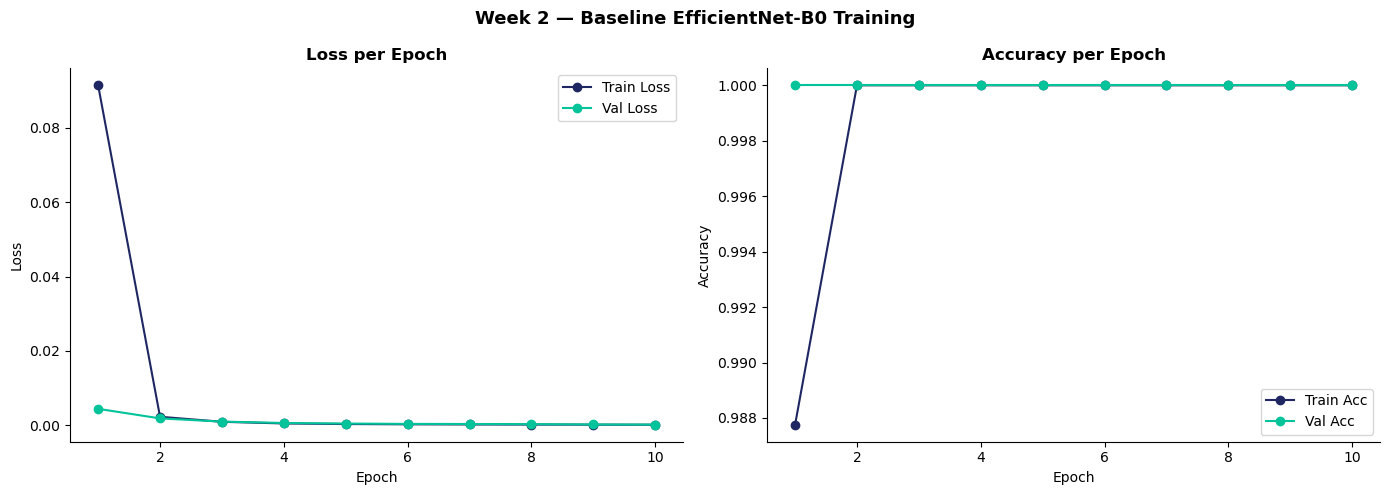

Training curves saved: C:\adversarial_doc_project\outputs\week2_training_curves.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Week 2 — Baseline EfficientNet-B0 Training", fontsize=13, fontweight="bold")

epochs = range(1, NUM_EPOCHS + 1)

# Loss
ax = axes[0]
ax.plot(epochs, history["train_loss"], color="#1E2761", marker="o", label="Train Loss")
ax.plot(epochs, history["val_loss"],   color="#02C39A", marker="o", label="Val Loss")
ax.set_title("Loss per Epoch", fontweight="bold")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.legend()
ax.spines[["top","right"]].set_visible(False)

# Accuracy
ax = axes[1]
ax.plot(epochs, history["train_acc"], color="#1E2761", marker="o", label="Train Acc")
ax.plot(epochs, history["val_acc"],   color="#02C39A", marker="o", label="Val Acc")
ax.set_title("Accuracy per Epoch", fontweight="bold")
ax.set_xlabel("Epoch")
ax.set_ylabel("Accuracy")
ax.legend()
ax.spines[["top","right"]].set_visible(False)

plt.tight_layout()
out = OUTPUTS_DIR / "week2_training_curves.png"
plt.savefig(out, dpi=150, bbox_inches="tight")
plt.show()
print(f"Training curves saved: {out}")


## Full Evaluation on Validation Set

In [10]:
# Load best model
checkpoint = torch.load(best_model_path, map_location=DEVICE, weights_only=True)
model.load_state_dict(checkpoint["model_state"])
print(f"Loaded best model from epoch {checkpoint['epoch']}")

# Evaluate on validation set
_, _, val_preds, val_labels = evaluate(model, val_loader, criterion, DEVICE)

# Metrics
f1        = f1_score(val_labels, val_preds, average="weighted", zero_division=0)
precision = precision_score(val_labels, val_preds, average="weighted", zero_division=0)
recall    = recall_score(val_labels, val_preds, average="weighted", zero_division=0)

print()
print("=" * 50)
print("BASELINE MODEL — VALIDATION RESULTS")
print("=" * 50)
print(f"  F1 Score  : {f1:.4f}")
print(f"  Precision : {precision:.4f}")
print(f"  Recall    : {recall:.4f}")
print("=" * 50)
print()
print("Per-class report:")
print(classification_report(
    val_labels, val_preds,
    labels=[0, 1, 2],
    target_names=CLASS_LIST,
    zero_division=0
))

Loaded best model from epoch 1



BASELINE MODEL — VALIDATION RESULTS
  F1 Score  : 1.0000
  Precision : 1.0000
  Recall    : 1.0000

Per-class report:
              precision    recall  f1-score   support

        real       1.00      1.00      1.00      1050
      benign       0.00      0.00      0.00         0
   malicious       0.00      0.00      0.00         0

   micro avg       1.00      1.00      1.00      1050
   macro avg       0.33      0.33      0.33      1050
weighted avg       1.00      1.00      1.00      1050



## Confusion Matrix

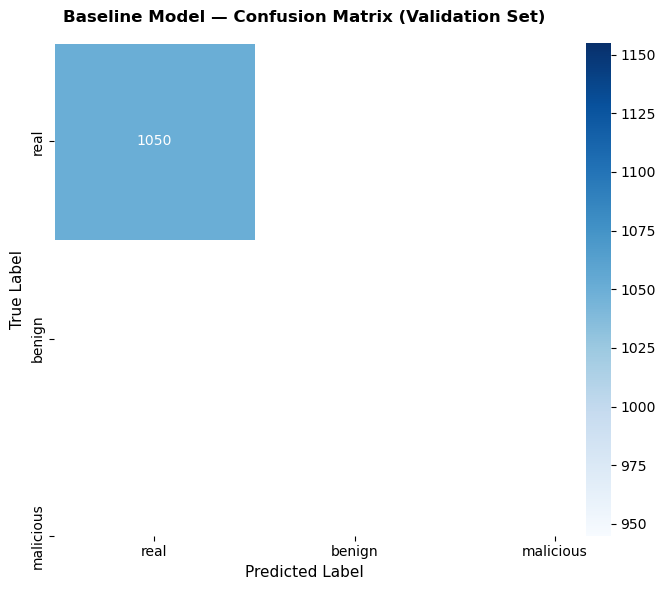

Confusion matrix saved: C:\adversarial_doc_project\outputs\week2_confusion_matrix.png


In [11]:
cm = confusion_matrix(val_labels, val_preds)

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=CLASS_LIST,
            yticklabels=CLASS_LIST,
            linewidths=0.5, ax=ax)
ax.set_title("Baseline Model — Confusion Matrix (Validation Set)",
             fontsize=12, fontweight="bold", pad=15)
ax.set_xlabel("Predicted Label", fontsize=11)
ax.set_ylabel("True Label", fontsize=11)

plt.tight_layout()
out = OUTPUTS_DIR / "week2_confusion_matrix.png"
plt.savefig(out, dpi=150, bbox_inches="tight")
plt.show()
print(f"Confusion matrix saved: {out}")


## Final Evaluation on Test Set

In [12]:
# Evaluate on held-out test set
_, test_acc, test_preds, test_labels = evaluate(model, test_loader, criterion, DEVICE)

test_f1        = f1_score(test_labels, test_preds, average="weighted", zero_division=0)
test_precision = precision_score(test_labels, test_preds, average="weighted", zero_division=0)
test_recall    = recall_score(test_labels, test_preds, average="weighted", zero_division=0)

print("=" * 50)
print("BASELINE MODEL — TEST SET RESULTS")
print("=" * 50)
print(f"  Accuracy  : {test_acc:.4f}")
print(f"  F1 Score  : {test_f1:.4f}")
print(f"  Precision : {test_precision:.4f}")
print(f"  Recall    : {test_recall:.4f}")
print("=" * 50)


BASELINE MODEL — TEST SET RESULTS
  Accuracy  : 1.0000
  F1 Score  : 1.0000
  Precision : 1.0000
  Recall    : 1.0000
